# Analyzing Profit Erosion from Product Returns in E-Commerce

## A Multi-Method Analytics Framework

**Course**: DAMO-699-4 - Winter 2026 Capstone Project  
**Institution**: University of Niagara Falls, Canada  
**Professor**: Omid Isfahanialamdari

---

## Research Questions

| RQ | Focus | Method |
|----|-------|--------|
| RQ1 | Profit erosion differences across product categories/brands | Descriptive Analysis |
| RQ2 | Customer behavioral segments with differential profit erosion | Unsupervised Learning (Clustering) |
| RQ3 | Predict high profit erosion customers (target AUC > 0.70) | Predictive Modeling (ML) |
| RQ4 | Marginal associations between behaviors and profit erosion | Econometric Regression |
| RQ5 | Optimal intervention thresholds (Optional) | Prescriptive Analytics |

---

## Key Metrics

- **Margin Reversal**: `sale_price - cost` for returned items
- **Processing Cost**: Estimated cost per return (category-adjusted)
- **Profit Erosion**: `margin_reversal + processing_cost` (for returned items only)

---

## Notebook Structure

1. **Setup** - Environment configuration and module imports
2. **Data Loading** - Build raw merged dataset from source files
3. **Data Cleaning** - Quality validation and flagging
4. **Feature Engineering** - Apply return flags, margins, profit erosion calculations
5. **RQ1: Descriptive Analysis** - Profit erosion by category/brand
6. **RQ2: Customer Segmentation** - Clustering by return behavior
7. **RQ3: Predictive Modeling** - ML models for high-risk identification
8. **RQ4: Econometric Analysis** - Regression analysis
9. **Summary & Conclusions**

---

## 1. Setup and Imports

In [1]:
# Standard library imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Reload modules to ensure latest changes are loaded
import importlib
modules_to_reload = [
    'src.config',
    'src.data_processing',
    'src.feature_engineering',
    'src.data_cleaning',
    'src.visualization',
    'src.modeling'
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project configuration
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, PROCESSED_PARQUET

# Data processing (raw data only)
from src.data_processing import (
    load_raw_data,
    merge_datasets,
    standardize_dtypes,
    build_analysis_dataset,
    load_processed_data,
)

# Feature engineering (applied after data processing)
from src.feature_engineering import (
    engineer_return_features,
    calculate_margins,
)

# Data cleaning
from src.data_cleaning import (
    perform_deep_clean,
    save_cleaned_dataset,
)

# Visualization
from src.visualization import (
    set_plot_style,
    plot_status_distribution,
    plot_return_rate_by_category,
    plot_margin_distribution,
    plot_margin_loss_by_category,
    plot_customer_margin_exposure,
    plot_return_rate_heatmap,
    plot_price_margin_returned_by_status_country,
)

# Modeling
from src.modeling import (
    calculate_return_rates_by_group,
    calculate_margin_loss_by_group,
    build_customer_behavior_profile,
    calculate_customer_margin_exposure,
    summarize_profit_erosion,
    segment_customers_by_return_behavior,
    calculate_price_margin_returned_by_country,
)

# Set plotting style
set_plot_style()

print(f"Project root: {project_root}")
print(f"Raw data dir: {RAW_DATA_DIR}")
print(f"Processed data dir: {PROCESSED_DATA_DIR}")
print("\n All modules loaded successfully")

Project root: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project
Raw data dir: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\data\raw
Processed data dir: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\data\processed

 All modules loaded successfully


---

## 2. Data Loading

Build the raw merged dataset from source CSV files. The `build_analysis_dataset()` function:
1. Loads raw CSV files (order_items, orders, products, users)
2. Merges them at order-item grain level
3. Standardizes data types
4. Saves to parquet/csv for future use

In [2]:
# Build raw merged dataset from source files
# This loads, merges, and standardizes types - no feature engineering applied yet
print("Building raw merged dataset from source files...")
df_raw = build_analysis_dataset(save_output=True)

print(f"\nDataset built:")
print(f"  Rows: {len(df_raw):,}")
print(f"  Columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())

Building raw merged dataset from source files...

Dataset built:
  Rows: 180,908
  Columns: 39

Column names:
['order_item_id', 'order_id', 'product_id', 'inventory_item_id', 'item_status', 'created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'first_name', 'last_name', 'email', 'age', 'user_gender', 'state', 'street_address', 'postal_code', 'city', 'country', 'latitude', 'longitude', 'traffic_source', 'user_created_at', 'user_geom']


---

## 3. Data Cleaning

Apply comprehensive data quality validation using the data_cleaning module. This step validates and flags issues in the raw data before feature engineering.

In [3]:
# Perform comprehensive deep cleaning on raw data
print("Performing data quality validation...")
print(f"Initial dataset: {len(df_raw):,} rows")

df_cleaned, cleaning_report = perform_deep_clean(
    df_raw,
    remove_duplicates=True,
    handle_missing="report",
    detect_outliers=True,
    validate_prices=True,
    validate_status=True,
    validate_temporal=True,
    clean_categories=True,
    remove_low_variance=False,
    outlier_action="flag",
    price_action="flag",
    status_action="flag",
    temporal_action="flag",
)

print(f"\nCleaned dataset: {len(df_cleaned):,} rows")
print(f"Rows removed: {cleaning_report['summary'].get('rows_removed', 0):,}")
print(f"Outliers flagged: {cleaning_report.get('outliers', {}).get('total_outlier_rows', 0):,}")

Performing data quality validation...
Initial dataset: 180,908 rows

Cleaned dataset: 180,908 rows
Rows removed: 0
Outliers flagged: 63,108


---

## 4. Feature Engineering

Apply feature engineering functions to the cleaned data to create analysis-ready columns:
- **Return flags**: `is_returned_item`, `is_returned_order`
- **Margin metrics**: `item_margin`, `item_margin_pct`, `discount_amount`, `discount_pct`

In [4]:
# Apply feature engineering to cleaned data
print("Applying feature engineering...")

# Step 1: Engineer return features
df = engineer_return_features(df_cleaned)
print(f"  Added return flags: is_returned_item, is_returned_order")
print(f"    Return rate: {df['is_returned_item'].mean() * 100:.2f}%")

# Step 2: Calculate margins
df = calculate_margins(df)
print(f"  Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct")
print(f"    Mean item margin: ${df['item_margin'].mean():.2f}")

print(f"\nFinal dataset: {len(df):,} rows, {len(df.columns)} columns")

Applying feature engineering...
  Added return flags: is_returned_item, is_returned_order
    Return rate: 10.06%
  Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct
    Mean item margin: $31.04

Final dataset: 180,908 rows, 51 columns


---

## 5. RQ1: Descriptive Analysis

**Research Question**: What are the profit erosion differences across product categories and brands?

### 5.1 Order Item Status Distribution

In [5]:
# Item status distribution
status_dist = (
    df.groupby("item_status")
    .agg(
        count=("item_status", "size"),
        avg_margin=("item_margin", "mean"),
        total_margin=("item_margin", "sum"),
    )
    .sort_values("count", ascending=False)
)
status_dist

,count,avg_margin,total_margin
item_status,,,
shipped,53931,30.747086,1.658221e+06
complete,45277,31.063903,1.406480e+06
processing,36215,31.374785,1.136238e+06
cancelled,27277,31.167442,8.501543e+05
returned,18208,30.991572,5.642945e+05


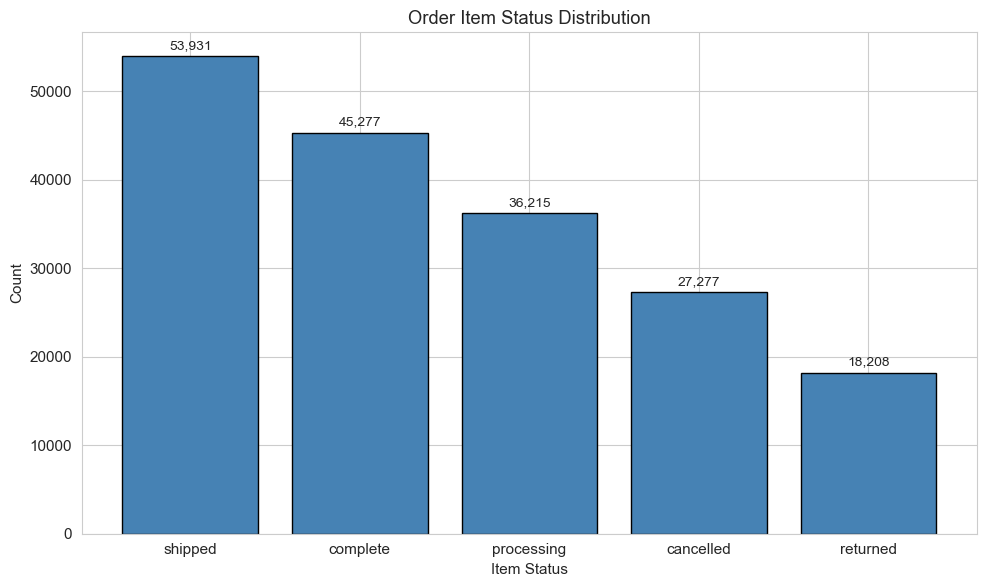

In [6]:
# Visualize status distribution
fig = plot_status_distribution(df)
plt.show()

### 5.2 Return Rate Analysis by Category

In [7]:
# Return rate by category and brand
ret_by_cat_brand = calculate_return_rates_by_group(
    df, 
    group_cols=["category", "brand"], 
    min_rows=200
)
ret_by_cat_brand.head(20)

,,item_rows,returned_items,return_rate
category,brand,,,
shorts,american apparel,204,31,0.151961
tops & tees,harley-davidson,207,31,0.149758
active,exofficio,217,32,0.147465
pants,orvis,217,32,0.147465
maternity,three seasons maternity,253,36,0.142292
shorts,o'neill,239,32,0.133891
suits & sport coats,allegra k,347,46,0.132565
maternity,a pea in the pod,234,31,0.132479
socks,hanes,210,27,0.128571


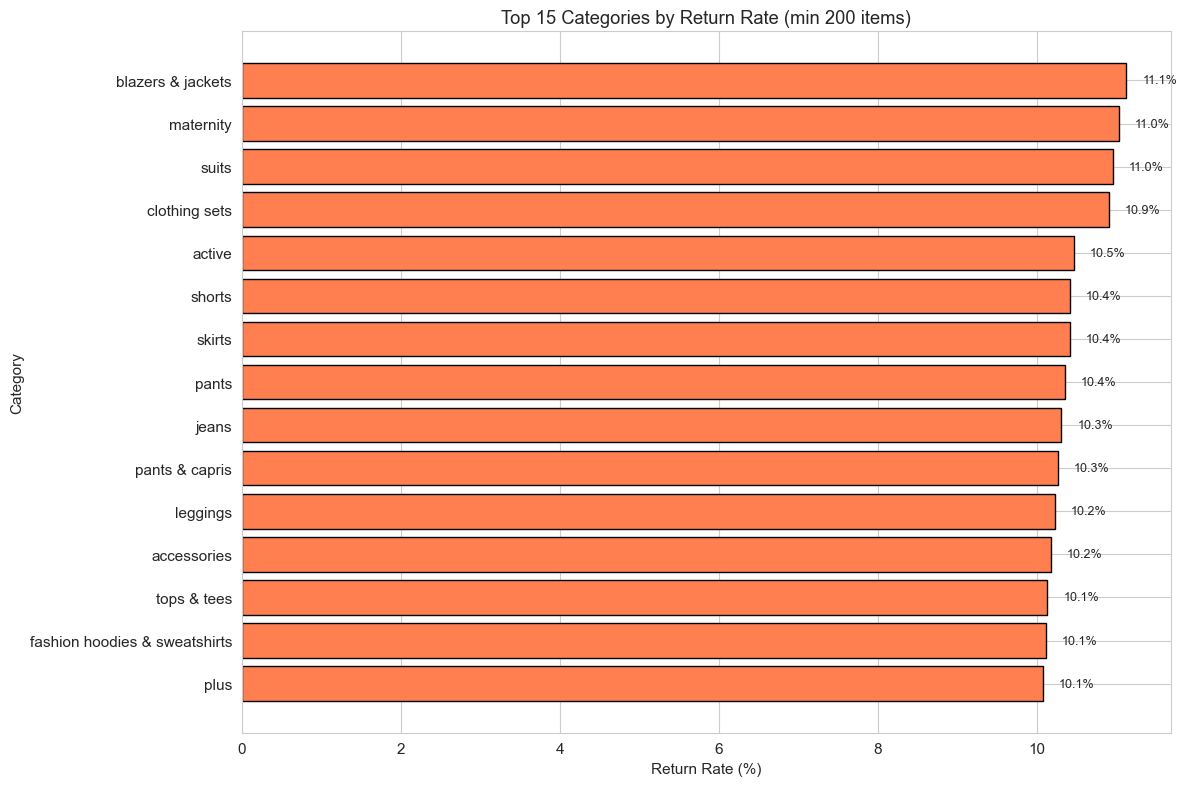

In [8]:
# Visualize return rates by category
fig = plot_return_rate_by_category(df, top_n=15, min_rows=200)
plt.show()

### 5.3 Margin Loss by Category

In [9]:
# Margin loss by category
margin_loss_by_category = calculate_margin_loss_by_group(df, group_cols=["category"])
margin_loss_by_category.head(15)

,returned_items,total_lost_sales,total_lost_margin,median_margin_per_return,avg_margin_per_return
category,,,,,
outerwear & coats,931,137944.849823,76693.733705,60.496000,82.377802
jeans,1286,123909.350129,57359.967938,35.875174,44.603397
sweaters,1109,85196.299951,44052.767296,31.107509,39.722964
suits & sport coats,492,61166.229997,36525.572048,56.794319,74.238968
fashion hoodies & sweatshirts,1192,64985.290035,31203.595301,23.518600,26.177513
sleep & lounge,1094,57169.620177,29629.574551,19.971220,27.083706
swim,1069,60293.780057,29523.019460,22.535309,27.617418
active,947,46321.120052,26747.333446,19.437000,28.244280
accessories,996,43717.559963,26296.765952,15.035990,26.402375


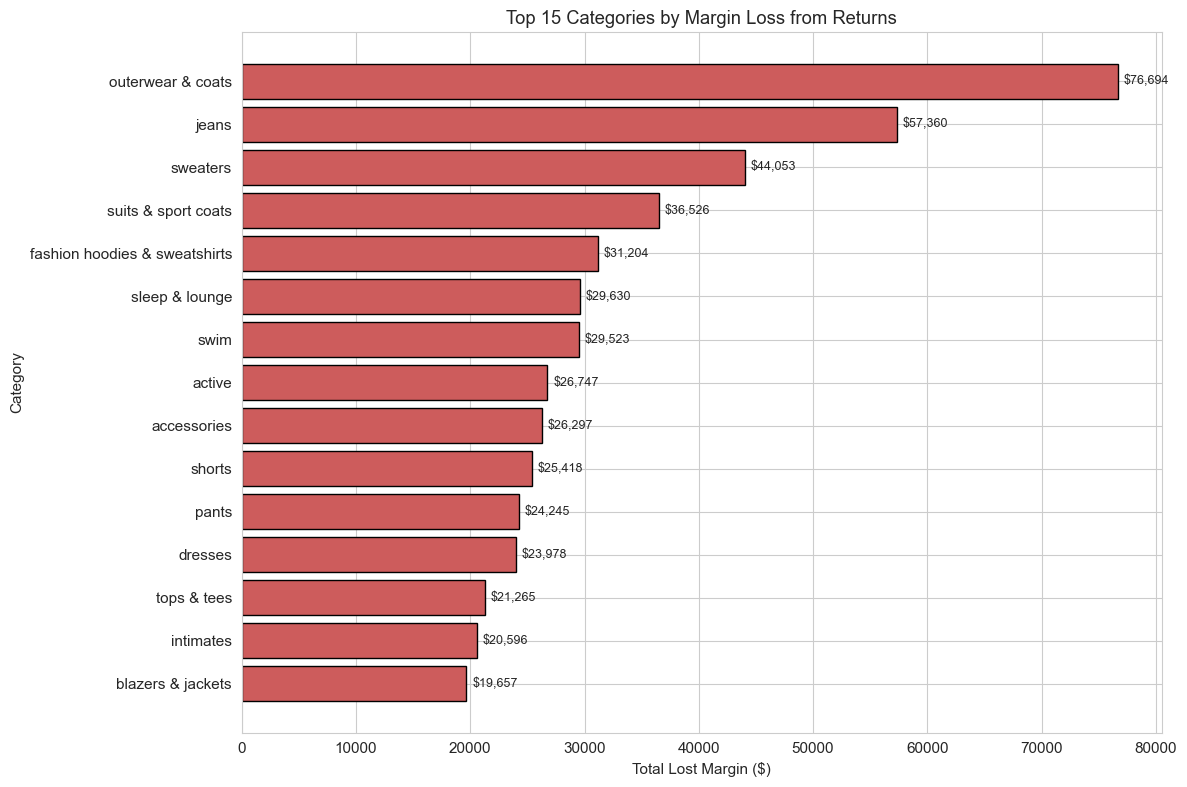

In [10]:
# Visualize margin loss by category
fig = plot_margin_loss_by_category(df, top_n=15)
plt.show()

### 5.4 Profit Erosion Summary

In [11]:
# Generate profit erosion summary
# Note: Using $15 as placeholder - will be replaced with category-adjusted costs
erosion_summary = summarize_profit_erosion(df, cost_per_return=15.0)

print("=" * 50)
print("PROFIT EROSION SUMMARY")
print("=" * 50)
print(f"Total items analyzed: {erosion_summary['total_items']:,}")
print(f"Total returned items: {erosion_summary['total_returned']:,}")
print(f"Return rate: {erosion_summary['return_rate_pct']:.2f}%")
print()
print(f"Total margin reversal: ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"Avg margin per return: ${erosion_summary['avg_margin_per_return']:.2f}")
print(f"Median margin per return: ${erosion_summary['median_margin_per_return']:.2f}")
print()
print(f"Estimated process costs (@$15/return): ${erosion_summary['estimated_process_costs']:,.2f}")
print(f"TOTAL PROFIT EROSION: ${erosion_summary['total_profit_erosion']:,.2f}")
print()
print(f"% of total margin lost to returns: {erosion_summary['pct_margin_lost_to_returns']:.2f}%")
print("=" * 50)

PROFIT EROSION SUMMARY
Total items analyzed: 180,908
Total returned items: 18,208
Return rate: 10.06%

Total margin reversal: $564,294.54
Avg margin per return: $30.99
Median margin per return: $20.52

Estimated process costs (@$15/return): $273,120.00
TOTAL PROFIT EROSION: $837,414.54

% of total margin lost to returns: 10.05%


---

## 6. RQ2: Customer Segmentation

**Research Question**: What customer behavioral segments exist with differential profit erosion?

### 6.1 Customer Behavior Profile

In [12]:
# Build customer behavior profile
customer_behavior = build_customer_behavior_profile(df)
customer_behavior.describe()

,total_items,total_orders,return_events,total_sales,total_margin,avg_item_price,avg_item_margin,avg_discount_pct,delivered_items,return_rate,items_per_order
count,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.0,79944.000000,79944.000000,79944.000000
mean,2.262934,1.562381,0.227759,135.255333,70.241521,59.951178,31.157664,0.0,0.773817,0.100789,1.449275
std,1.600215,0.859629,0.643842,138.479309,74.077067,54.003167,29.776293,0.0,1.129507,0.269227,0.716939
min,1.000000,1.000000,0.000000,0.490000,0.312620,0.490000,0.312620,0.0,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,42.000000,21.076000,29.990000,15.000000,0.0,0.000000,0.000000,1.000000
50%,2.000000,1.000000,0.000000,89.500000,45.737684,46.975000,23.588643,0.0,0.000000,0.000000,1.000000
75%,3.000000,2.000000,0.000000,182.490000,94.136147,71.970000,37.288034,0.0,1.000000,0.000000,2.000000
max,13.000000,4.000000,8.000000,1733.430000,981.555083,999.000000,568.099998,0.0,10.000000,1.000000,4.000000


### 6.2 Customer Segmentation by Return Behavior

In [13]:
# Segment customers by return behavior
customer_segments = segment_customers_by_return_behavior(
    df, 
    return_rate_thresholds=(0.05, 0.15)
)

# Segment distribution
segment_counts = customer_segments["return_segment"].value_counts()
print("Customer Segment Distribution:")
print(segment_counts)
print(f"\nTotal customers: {len(customer_segments):,}")

Customer Segment Distribution:
return_segment
no_returns           67956
high_returner        11718
moderate_returner      270
Name: count, dtype: int64

Total customers: 79,944


In [14]:
# Analyze segments
segment_summary = (
    customer_segments
    .groupby("return_segment")
    .agg(
        customer_count=("total_items", "count"),
        avg_items=("total_items", "mean"),
        avg_returns=("return_events", "mean"),
        avg_return_rate=("return_rate", "mean"),
        total_margin=("total_margin", "sum"),
    )
    .round(2)
)
segment_summary

,customer_count,avg_items,avg_returns,avg_return_rate,total_margin
return_segment,,,,,
high_returner,11718,2.76,1.53,0.68,998687.15
moderate_returner,270,7.54,1.00,0.13,62615.91
no_returns,67956,2.16,0.00,0.00,4554085.07


### 6.3 Customer Margin Exposure

In [15]:
# Customer margin exposure
customer_exposure = calculate_customer_margin_exposure(df)
customer_exposure.head(20)

,return_events,total_lost_margin,total_lost_sales,median_margin_per_return,max_single_return_margin
user_id,,,,,
46358,5,660.286698,1230.989998,36.476199,507.485999
73088,4,601.724230,1030.820002,29.405225,535.478999
9592,2,560.598027,991.769997,280.299013,503.873999
73720,2,555.082019,945.990002,277.541010,533.672998
48158,2,545.759348,925.990000,272.879674,532.769998
34216,1,535.478999,903.000000,535.478999,535.478999
79918,2,534.529997,1040.000000,267.264999,511.829997
7008,1,533.672998,903.000000,533.672998,533.672998
51888,1,532.769998,903.000000,532.769998,532.769998


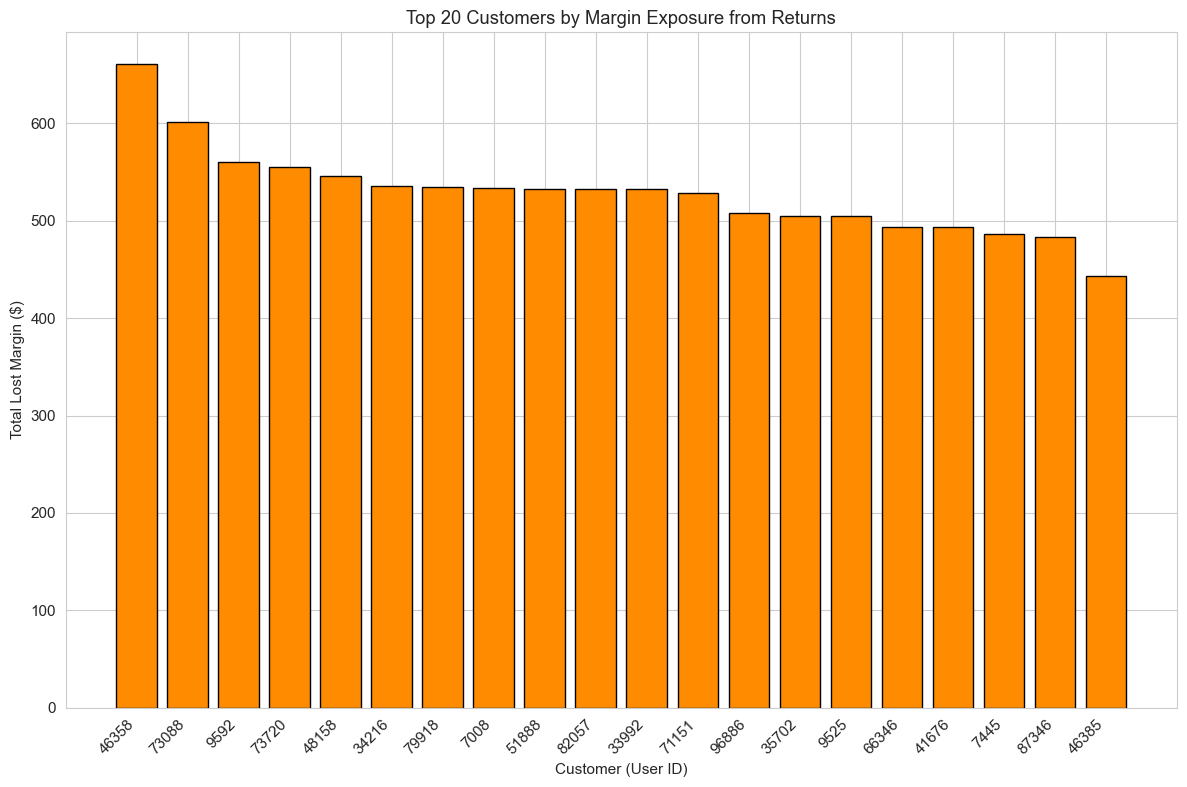

In [16]:
# Visualize customer margin exposure
fig = plot_customer_margin_exposure(df, top_n=20)
plt.show()

---

## 7. RQ3: Predictive Modeling

**Research Question**: Can we predict high profit erosion customers with AUC > 0.70?

*TODO: Implement predictive modeling*

In [17]:
# Placeholder for predictive modeling
print("RQ3: Predictive Modeling - To be implemented")
print("\nPlanned approach:")
print("  1. Define target variable (high profit erosion threshold)")
print("  2. Feature selection from customer behavior profiles")
print("  3. Train/test split with temporal consideration")
print("  4. Model training (Logistic Regression, Random Forest, XGBoost)")
print("  5. Evaluation metrics (AUC, Precision, Recall)")

RQ3: Predictive Modeling - To be implemented

Planned approach:
  1. Define target variable (high profit erosion threshold)
  2. Feature selection from customer behavior profiles
  3. Train/test split with temporal consideration
  4. Model training (Logistic Regression, Random Forest, XGBoost)
  5. Evaluation metrics (AUC, Precision, Recall)


---

## 8. RQ4: Econometric Analysis

**Research Question**: What are the marginal associations between customer behaviors and profit erosion?

*TODO: Implement regression analysis*

In [18]:
# Placeholder for econometric analysis
print("RQ4: Econometric Regression - To be implemented")
print("\nPlanned approach:")
print("  1. Define dependent variable (profit erosion per customer)")
print("  2. Select independent variables (demographics, behavior metrics)")
print("  3. OLS regression with robust standard errors")
print("  4. Coefficient interpretation and marginal effects")
print("  5. Model diagnostics (heteroscedasticity, multicollinearity)")

RQ4: Econometric Regression - To be implemented

Planned approach:
  1. Define dependent variable (profit erosion per customer)
  2. Select independent variables (demographics, behavior metrics)
  3. OLS regression with robust standard errors
  4. Coefficient interpretation and marginal effects
  5. Model diagnostics (heteroscedasticity, multicollinearity)


---

## 9. Summary & Conclusions

*To be completed after all analyses*

In [19]:
# Summary placeholder
print("Analysis Summary")
print("=" * 50)
print(f"Dataset: {len(df):,} order items")
print(f"Return rate: {df['is_returned_item'].mean() * 100:.2f}%")
print(f"Total margin reversal: ${df[df['is_returned_item']==1]['item_margin'].sum():,.2f}")

Analysis Summary
Dataset: 180,908 order items
Return rate: 10.06%
Total margin reversal: $564,294.54
